# Linear Regression on Population vs Profit

This notebook loads `PopulationProfit.csv`, visualises the data, fits a linear regression model using **scikit-learn**, and visualises the learned parameters (theta).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 1. Load & Explore the Data

In [2]:
df = pd.read_csv('PopulationProfit.csv', header=None, names=['Population', 'Profit'])
print(f'Shape: {df.shape}')
df.describe()

Shape: (97, 2)


,Population,Profit
count,97.000000,97.000000
mean,8.159800,5.839135
std,3.869884,5.510262
min,5.026900,-2.680700
25%,5.707700,1.986900
50%,6.589400,4.562300
75%,8.578100,7.046700
max,22.203000,24.147000


## 2. Visualise the Raw Data

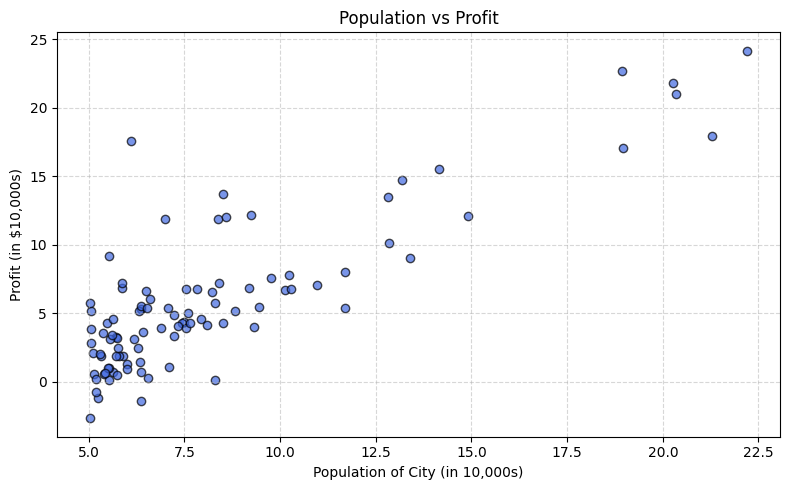

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Population'], df['Profit'], c='royalblue', edgecolors='k', alpha=0.7)
plt.xlabel('Population of City (in 10,000s)')
plt.ylabel('Profit (in $10,000s)')
plt.title('Population vs Profit')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Linear Regression with scikit-learn

In [4]:
X = df[['Population']].values   # shape (m, 1)
y = df['Profit'].values          # shape (m,)

model = LinearRegression()
model.fit(X, y)

theta_0 = model.intercept_       # bias / intercept
theta_1 = model.coef_[0]         # slope

print(f'Theta 0 (intercept): {theta_0:.4f}')
print(f'Theta 1 (slope):     {theta_1:.4f}')
print(f'R² score:            {r2_score(y, model.predict(X)):.4f}')
print(f'MSE:                 {mean_squared_error(y, model.predict(X)):.4f}')

Theta 0 (intercept): -3.8958
Theta 1 (slope):     1.1930
R² score:            0.7020
MSE:                 8.9539


## 4. Visualise the Regression Line

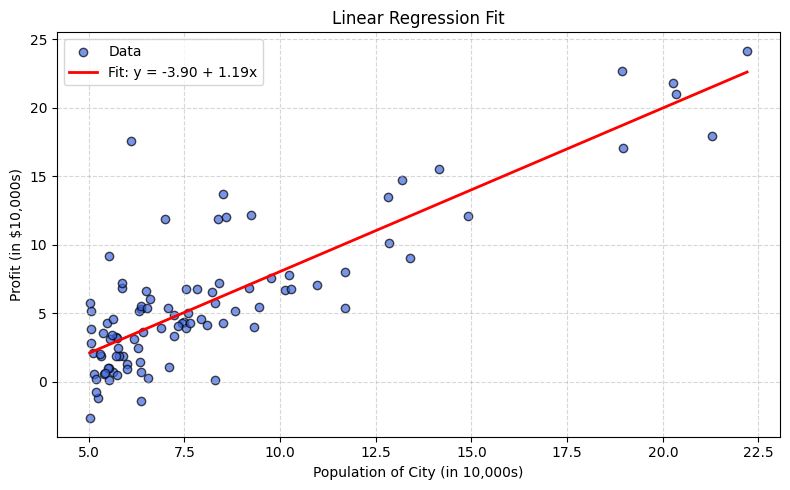

In [5]:
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, c='royalblue', edgecolors='k', alpha=0.7, label='Data')
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'Fit: y = {theta_0:.2f} + {theta_1:.2f}x')
plt.xlabel('Population of City (in 10,000s)')
plt.ylabel('Profit (in $10,000s)')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Visualise Theta (Model Parameters)

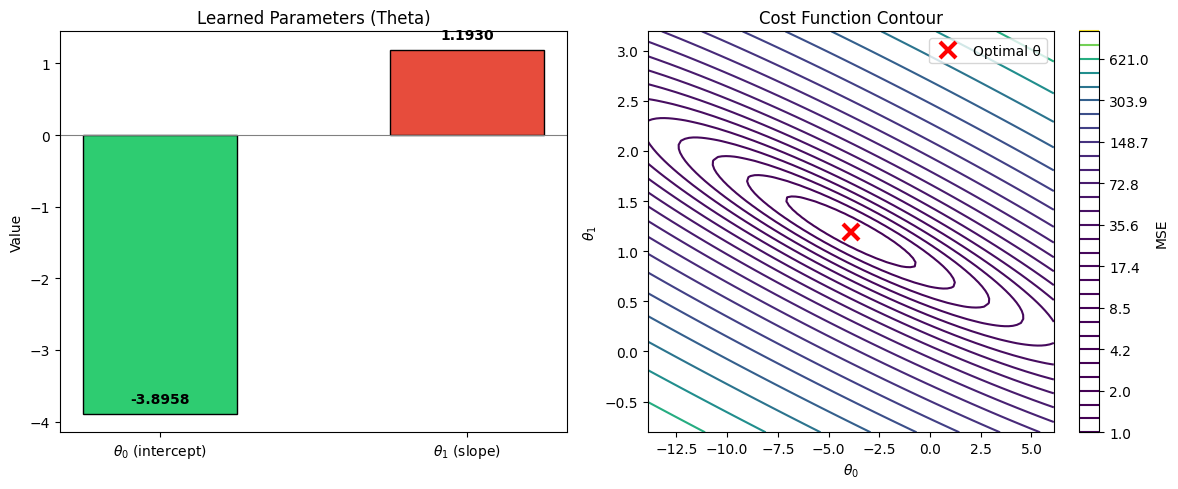

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart of theta values
params = [theta_0, theta_1]
labels = [r'$\theta_0$ (intercept)', r'$\theta_1$ (slope)']
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(labels, params, color=colors, edgecolor='k', width=0.5)
axes[0].set_ylabel('Value')
axes[0].set_title('Learned Parameters (Theta)')
axes[0].axhline(0, color='grey', linewidth=0.8)
for i, v in enumerate(params):
    axes[0].text(i, v + 0.15, f'{v:.4f}', ha='center', fontweight='bold')

# Cost surface (MSE) over a grid of theta_0 and theta_1
t0_range = np.linspace(theta_0 - 10, theta_0 + 10, 100)
t1_range = np.linspace(theta_1 - 2, theta_1 + 2, 100)
T0, T1 = np.meshgrid(t0_range, t1_range)
Cost = np.zeros_like(T0)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        pred = T0[i, j] + T1[i, j] * X.flatten()
        Cost[i, j] = np.mean((pred - y) ** 2)

cs = axes[1].contour(T0, T1, Cost, levels=np.logspace(0, 3, 30), cmap='viridis')
axes[1].plot(theta_0, theta_1, 'rx', markersize=12, markeredgewidth=3, label='Optimal θ')
axes[1].set_xlabel(r'$\theta_0$')
axes[1].set_ylabel(r'$\theta_1$')
axes[1].set_title('Cost Function Contour')
axes[1].legend()
plt.colorbar(cs, ax=axes[1], label='MSE')

plt.tight_layout()
plt.show()

## 6. Residual Analysis

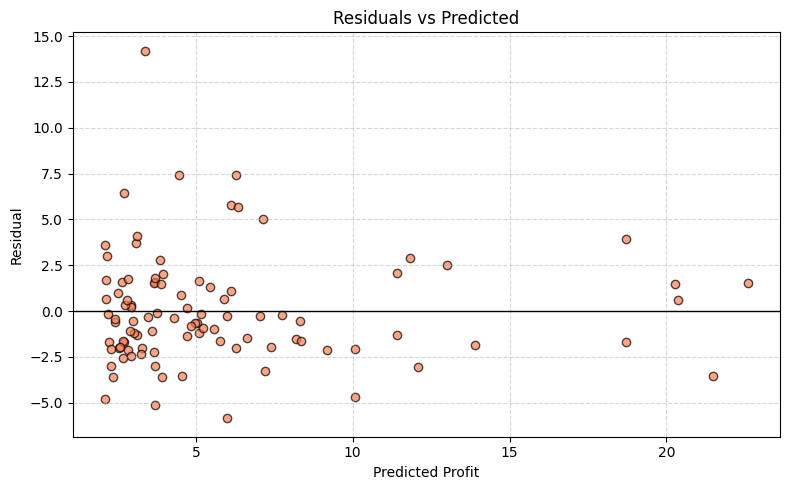

In [7]:
residuals = y - model.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(model.predict(X), residuals, c='coral', edgecolors='k', alpha=0.7)
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Predicted Profit')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()